### Chapter 4 — Part 7

### The Problem with Absolute Value

# Chapter 4 — Part 7
# The Problem with Absolute Value

> **Core Question:**  
> Why can taking the absolute value of a distance become a problem when we are dealing with classification?

In the previous parts of Chapter 4, we developed the idea of a decision boundary and learned that a point can have a **signed distance** from that boundary.

A signed distance contains two pieces of information:

1. **Magnitude** → How far is the point from the boundary?
2. **Sign** → On which side of the boundary is the point?

In this part, we will understand what happens when we apply **absolute value**.

The central idea is:

$$
\boxed{\text{Absolute value preserves magnitude but removes sign.}}
$$

And in classification, that lost sign can contain important information.

## 1. Why Are We Talking About Absolute Value?

Let's temporarily forget Machine Learning.

Consider two numbers:

$$
+5
$$

and

$$
-5
$$

Both numbers are exactly 5 units away from zero.

Therefore:

$$
|+5| = 5
$$

and:

$$
|-5| = 5
$$

So:

$$
\boxed{|+5| = |-5|}
$$

This immediately tells us something important about absolute value:

> **Absolute value tells us the magnitude or distance from zero, but it does not tell us the direction.**

## 2. Visualizing Absolute Value on a Number Line

Consider the number line:

$$
-5 \qquad\qquad 0 \qquad\qquad +5
$$

The points \(-5\) and \(+5\) are on opposite sides of zero.

But their distances from zero are identical:

$$
|-5| = |+5| = 5
$$

Let's visualize this directly in Python.

## Code

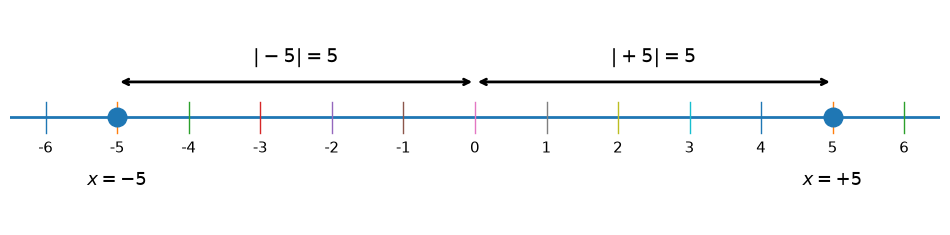

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.8))

# Number line
ax.axhline(0, linewidth=2)

# Ticks
for i in range(-6, 7):
    ax.plot([i, i], [-0.08, 0.08], linewidth=1)
    ax.text(i, -0.18, str(i), ha="center", fontsize=11)

# Points
ax.scatter([-5, 5], [0, 0], s=180, zorder=3)

# Distance arrows
ax.annotate(
    "",
    xy=(-5, 0.18),
    xytext=(0, 0.18),
    arrowprops=dict(arrowstyle="<->", linewidth=2)
)

ax.annotate(
    "",
    xy=(0, 0.18),
    xytext=(5, 0.18),
    arrowprops=dict(arrowstyle="<->", linewidth=2)
)

# Labels
ax.text(-2.5, 0.28, r"$|-5| = 5$", ha="center", fontsize=14)
ax.text(2.5, 0.28, r"$|+5| = 5$", ha="center", fontsize=14)

ax.text(-5, -0.35, r"$x=-5$", ha="center", fontsize=13)
ax.text(5, -0.35, r"$x=+5$", ha="center", fontsize=13)

ax.set_xlim(-6.5, 6.5)
ax.set_ylim(-0.55, 0.55)
ax.axis("off")

plt.show()

### What we learn
Both sides have the same distance:  

$$5$$

but opposite directions.

## 3. Magnitude vs Direction

A signed number contains two kinds of information.

For example:

$$
-5
$$

contains:

### Magnitude

$$
5
$$

### Direction

Negative / left side of zero.

Similarly:

$$
+5
$$

contains:

### Magnitude

$$
5
$$

### Direction

Positive / right side of zero.

Therefore:

| Value | Magnitude | Direction |
|---|---:|---|
| \(+5\) | 5 | Positive |
| \(-5\) | 5 | Negative |

After applying absolute value:

| Value | Absolute Value |
|---|---:|
| \(+5\) | 5 |
| \(-5\) | 5 |

The magnitude survives.

The sign disappears.

Therefore:

$$
\boxed{\text{Absolute value preserves magnitude but removes direction/sign.}}
$$

## 4. What Exactly Does Absolute Value Remove?

Let's compare:

$$
x = +3
$$

and:

$$
x = -3
$$

Before applying absolute value:

$$
+3 \neq -3
$$

They represent different positions and opposite directions.

After applying absolute value:

$$
|+3| = 3
$$

and:

$$
|-3| = 3
$$

Therefore:

$$
|+3| = |-3|
$$

The two values become identical.

So absolute value has removed the information that distinguishes:

$$
\boxed{\text{positive direction}}
$$

from:

$$
\boxed{\text{negative direction}}
$$

This is perfectly fine if we only care about **distance**.

But it becomes a problem when the sign carries meaningful information.

## 5. Why Does Direction Matter in Machine Learning?

Now let's return to our decision boundary.

A linear decision boundary is represented by:

$$
w^Tx+b=0
$$

For a point \(x\), we calculate:

$$
w^Tx+b
$$

The result is called the **decision score** (or raw score).

The important observation is that its **sign** tells us which side of the decision boundary the point lies on.

For example:

$$
w^Tx+b > 0
$$

means the point is on one side.

Whereas:

$$
w^Tx+b < 0
$$

means the point is on the opposite side.

Therefore, the sign is meaningful for classification.

$$
\boxed{
\text{Sign} \rightarrow \text{side of the decision boundary}
}
$$

## 6. A Simple Decision Boundary Example

Consider the one-dimensional decision boundary:

$$
x=0
$$

This divides the number line into two regions:

$$
x<0
$$

and:

$$
x>0
$$

Let's choose two points:

$$
x_1=-4
$$

and:

$$
x_2=+4
$$

They are equally far from the boundary:

$$
|-4|=|+4|=4
$$

But they are on opposite sides:

$$
x_1 < 0
$$

and:

$$
x_2 > 0
$$

So:

$$
\boxed{
\text{same distance} \neq \text{same side}
}
$$

This is the key idea behind the problem with absolute value.

## 7. Visualizing the Two Sides

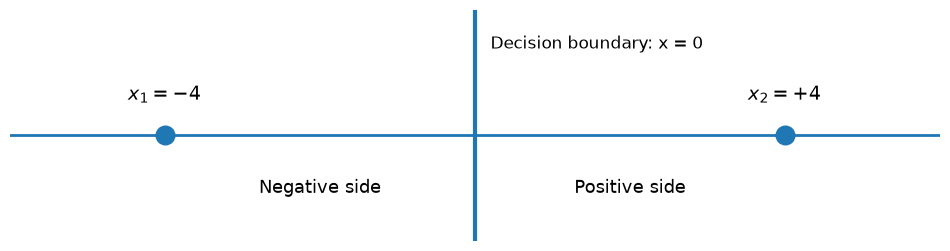

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

# Number line / decision boundary
ax.axhline(0, linewidth=2)

# Decision boundary at x = 0
ax.axvline(0, linewidth=3)

# Points
ax.scatter([-4, 4], [0, 0], s=180, zorder=3)

# Labels
ax.text(-4, 0.18, r"$x_1=-4$", ha="center", fontsize=14)
ax.text(4, 0.18, r"$x_2=+4$", ha="center", fontsize=14)

ax.text(-2, -0.3, "Negative side", ha="center", fontsize=13)
ax.text(2, -0.3, "Positive side", ha="center", fontsize=13)

ax.text(0.2, 0.45, "Decision boundary: x = 0", fontsize=12)

ax.set_xlim(-6, 6)
ax.set_ylim(-0.55, 0.65)
ax.axis("off")

plt.show()

## 8. The Dangerous Step — Taking Absolute Value

Suppose two points produce these signed values:

$$
+4
$$

and:

$$
-4
$$

Before taking absolute value:

$$
+4 \neq -4
$$

The signs tell us that the points are on opposite sides.

But after taking absolute value:

$$
|+4|=4
$$

and:

$$
|-4|=4
$$

Now:

$$
|+4|=|-4|
$$

The distance information remains.

The side information is gone.

Therefore:

$$
\boxed{
\text{Absolute value can destroy classification-relevant information.}
}
$$

## 9. Distance vs Signed Distance

This is one of the most important distinctions in this chapter.

For a decision boundary:

$$
w^Tx+b=0
$$

the perpendicular **signed distance** of a point \(x\) from the boundary is:

$$
\boxed{
d(x)=\frac{w^Tx+b}{\|w\|}
}
$$

Notice that there is **no absolute value** here.

Why?

Because we want to preserve the sign.

The sign tells us which side of the boundary the point lies on.

The magnitude tells us how far the point is from the boundary.

Therefore:

$$
d(x)>0
$$

and

$$
d(x)<0
$$

represent different sides.

The ordinary geometric distance, however, is always non-negative:

$$
\boxed{
\text{distance}(x)
=
\left|
\frac{w^Tx+b}{\|w\|}
\right|
}
$$

So we have:

### Signed Distance

$$
\frac{w^Tx+b}{\|w\|}
$$

Contains:

- Distance
- Side information

### Absolute Distance

$$
\left|
\frac{w^Tx+b}{\|w\|}
\right|
$$

Contains:

- Distance

But loses:

- Side information

## 10. The Three Quantities We Must Keep Separate

There are three related quantities that we should not confuse.

### 1. Decision score

$$
\boxed{
w^Tx+b
}
$$

This tells us which side of the boundary the point is on through its sign.

---

### 2. Signed perpendicular distance

$$
\boxed{
\frac{w^Tx+b}{\|w\|}
}
$$

This gives the actual perpendicular distance with a sign.

It tells us:

- How far?
- Which side?

---

### 3. Absolute perpendicular distance

$$
\boxed{
\left|
\frac{w^Tx+b}{\|w\|}
\right|
}
$$

This gives the ordinary geometric distance.

It tells us:

- How far?

But not:

- Which side?

Therefore:

$$
\boxed{
\text{Signed distance} = \text{magnitude + side information}
}
$$

while:

$$
\boxed{
\text{Absolute distance} = \text{magnitude only}
}
$$

## 11. A Concrete ML-Style Example

Suppose:

$$
\|w\|=2
$$

and two points produce:

$$
w^Tx_1+b=6
$$

and:

$$
w^Tx_2+b=-6
$$

Their signed distances are:

$$
d_1=\frac{6}{2}=3
$$

and:

$$
d_2=\frac{-6}{2}=-3
$$

Therefore:

$$
d_1=+3
$$

and:

$$
d_2=-3
$$

### Interpretation

- \(x_1\) is 3 units from the boundary on one side.
- \(x_2\) is 3 units from the boundary on the opposite side.

Now take absolute values:

$$
|d_1|=3
$$

and:

$$
|d_2|=3
$$

The two points now appear identical if we only look at absolute distance.

But they are actually on opposite sides.

This is exactly the information that absolute value removes.

## 12. Let's Verify This with Python

We can verify the difference between **signed distance** and **absolute distance** using NumPy.

We start with the decision scores:

$$
[6,-6]
$$

and assume:

$$
\|w\|=2
$$

The signed distances are calculated as:

$$
d=\frac{w^Tx+b}{\|w\|}
$$

Then we apply absolute value to obtain the ordinary distances.

In [3]:
import numpy as np

w_norm = 2

scores = np.array([6, -6])

signed_distances = scores / w_norm

absolute_distances = np.abs(signed_distances)

print("Scores:", scores)
print("Signed distances:", signed_distances)
print("Absolute distances:", absolute_distances)

Scores: [ 6 -6]
Signed distances: [ 3. -3.]
Absolute distances: [3. 3.]


### Expected Output

```text
Scores: [ 6 -6]
Signed distances: [ 3. -3.]
Absolute distances: [3. 3.]

### Notice the difference:

$$[3,−3]$$

becomes:

$$[3,3]$$

after applying absolute value.

The magnitude is preserved, but the sign is lost.

## 13. What Did We Lose?

Before applying absolute value:

$$
[+3,-3]
$$

We know:

- First point → positive side
- Second point → negative side

After applying absolute value:

$$
[3,3]
$$

We know:

- First point → 3 units away
- Second point → 3 units away

But we no longer know:

- Which point is on which side?

Therefore:

$$
\boxed{
[+3,-3]
\xrightarrow{\text{absolute value}}
[3,3]
}
$$

The magnitude survives.

The sign disappears.

## 14. A Better Mental Model

Think of a signed distance as answering **two questions simultaneously**.

### Question 1

> How far am I from the decision boundary?

The magnitude answers this.

### Question 2

> Which side of the decision boundary am I on?

The sign answers this.

For example:

$$
+7
$$

means:

> 7 units away, on the positive side.

While:

$$
-7
$$

means:

> 7 units away, on the negative side.

But:

$$
|-7|=7
$$

only tells us:

> 7 units away.

The side information has disappeared.

Therefore:

$$
\boxed{
\text{Signed distance}
=
\text{distance + direction}
}
$$

while:

$$
\boxed{
\text{Absolute distance}
=
\text{distance only}
}
$$

## 15. Important Nuance — Absolute Value Is Not "Bad"

We should not conclude:

> "Absolute value is bad."

That would be incorrect.

Absolute value is extremely useful whenever we only care about magnitude.

For example:

> How far is \(-8\) from zero?

The correct answer is:

$$
|-8|=8
$$

Here, the direction does not matter.

The problem occurs when the sign itself carries meaningful information.

Therefore, the precise statement is:

$$
\boxed{
\text{Absolute value is problematic only when sign information is important.}
}
$$

In classification, the sign can tell us which side of a decision boundary a point lies on.

Therefore, removing the sign can remove useful classification information.

## 16. The Big Picture

Let's connect the ideas developed throughout this chapter.

We start with the decision boundary:

$$
\boxed{
w^Tx+b=0
}
$$

For a particular point:

$$
\boxed{
w^Tx+b
}
$$

gives us a signed score.

Its sign tells us the side of the boundary.

To convert the score into actual perpendicular distance, we divide by:

$$
\|w\|
$$

giving:

$$
\boxed{
d(x)=\frac{w^Tx+b}{\|w\|}
}
$$

This is the **signed distance**.

It contains:

$$
\boxed{
\text{magnitude + side information}
}
$$

If we apply absolute value:

$$
\boxed{
|d(x)|
=
\left|
\frac{w^Tx+b}{\|w\|}
\right|
}
$$

we obtain ordinary geometric distance.

But:

$$
\boxed{
\text{side information is lost}
}
$$

Therefore:

$$
\boxed{
\text{Distance tells us HOW FAR.}
}
$$

$$
\boxed{
\text{Sign tells us WHICH SIDE.}
}
$$

$$
\boxed{
\text{Absolute value keeps the first and removes the second.}
}
$$

## 17. Final Visualization — Signed vs Absolute Distance

Let's visualize the difference between **signed distance** and **absolute distance**.

We will use points on both sides of the decision boundary:

$$
x \in \{-4,-2,-1,1,2,4\}
$$

For this simple one-dimensional example, the signed distance is:

$$
d=x
$$

and the absolute distance is:

$$
|d|=|x|
$$

The goal is to visually see what happens to the sign when we apply absolute value.

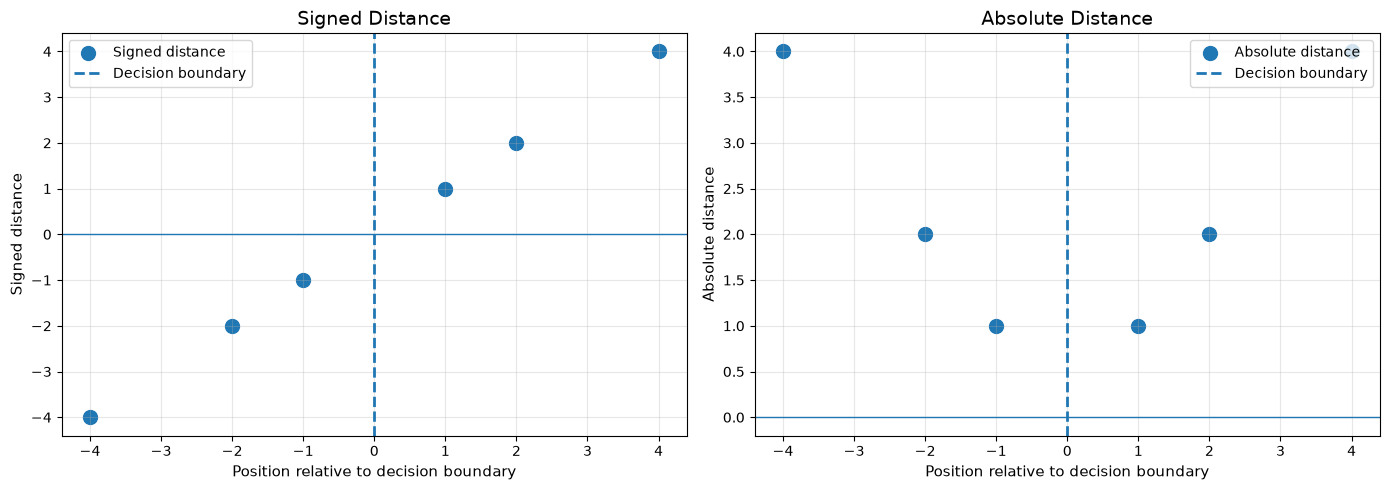

In [4]:
import matplotlib.pyplot as plt
import numpy as np

points = np.array([-4, -2, -1, 1, 2, 4])

signed_distance = points
absolute_distance = np.abs(points)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------------
# Signed Distance
# --------------------------------------------------

axes[0].scatter(
    points,
    signed_distance,
    s=100,
    label="Signed distance"
)

axes[0].axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Decision boundary"
)

axes[0].axhline(0, linewidth=1)

axes[0].set_xlabel(
    "Position relative to decision boundary",
    fontsize=11
)

axes[0].set_ylabel(
    "Signed distance",
    fontsize=11
)

axes[0].set_title(
    "Signed Distance",
    fontsize=14
)

axes[0].legend()
axes[0].grid(alpha=0.3)


# --------------------------------------------------
# Absolute Distance
# --------------------------------------------------

axes[1].scatter(
    points,
    absolute_distance,
    s=100,
    label="Absolute distance"
)

axes[1].axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Decision boundary"
)

axes[1].axhline(0, linewidth=1)

axes[1].set_xlabel(
    "Position relative to decision boundary",
    fontsize=11
)

axes[1].set_ylabel(
    "Absolute distance",
    fontsize=11
)

axes[1].set_title(
    "Absolute Distance",
    fontsize=14
)

axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### What to Observe

Consider the point:

$$
x=-4
$$

Its signed distance is:

$$
d=-4
$$

but its absolute distance is:

$$
|d|=4
$$

For the point:

$$
x=+4
$$

the signed distance is:

$$
d=+4
$$

but its absolute distance is also:

$$
|d|=4
$$

Therefore, the two points have:

- The same absolute distance from the decision boundary.
- Different signed distances.
- Different sides of the decision boundary.

The visualization makes the key idea clear:

$$
\boxed{
\text{Signed distance preserves the side information.}
}
$$

while:

$$
\boxed{
\text{Absolute distance removes the side information.}
}
$$

# Summary

We started with a simple observation:

$$
|-3|=3
$$

Absolute value gives us the magnitude/distance from zero.

However:

$$
|-3|=|+3|
$$

so it removes the sign.

In Machine Learning, the sign can be important because a linear decision boundary:

$$
w^Tx+b=0
$$

divides the space into two sides.

The signed distance:

$$
\boxed{
\frac{w^Tx+b}{\|w\|}
}
$$

contains both:

- **Magnitude** → how far from the boundary
- **Sign** → which side of the boundary

Taking absolute value:

$$
\boxed{
\left|
\frac{w^Tx+b}{\|w\|}
\right|
}
$$

preserves the magnitude but removes the side information.

Therefore:

$$
\boxed{
\text{Absolute value answers "How far?"}
}
$$

but:

$$
\boxed{
\text{it cannot answer "Which side?"}
}
$$

# ⭐ Key Takeaways

### 1. Absolute value removes sign

$$
|+a|=|-a|
$$

---

### 2. Magnitude and direction are different pieces of information

$$
+5 \neq -5
$$

even though:

$$
|+5|=|-5|
$$

---

### 3. A decision boundary separates space into two sides

$$
w^Tx+b=0
$$

---

### 4. The sign of the score tells us the side

$$
w^Tx+b>0
$$

and:

$$
w^Tx+b<0
$$

represent opposite sides.

---

### 5. Signed distance preserves both pieces of information

$$
\boxed{
d(x)=\frac{w^Tx+b}{\|w\|}
}
$$

---

### 6. Absolute distance removes the side information

$$
\boxed{
|d(x)|
=
\left|
\frac{w^Tx+b}{\|w\|}
\right|
}
$$

---

### 🧠 Remember

> **Distance tells us HOW FAR.**
>
> **Sign tells us WHICH SIDE.**
>
> **Absolute value keeps the distance but throws away the side.**

# 🧪 Self-Check

Try answering these without looking back.

### Q1.

Why do we have:

$$
|-5|=|+5|
$$

even though \(-5\) and \(+5\) represent different positions?

### Q2.

What information does absolute value preserve?

### Q3.

What information does absolute value remove?

### Q4.

For a decision boundary:

$$
w^Tx+b=0
$$

what does the sign of \(w^Tx+b\) tell us?

### Q5.

What is the difference between:

$$
\frac{w^Tx+b}{\|w\|}
$$

and:

$$
\left|
\frac{w^Tx+b}{\|w\|}
\right|
$$

### Q6.

Two points have signed distances:

$$
+4
$$

and:

$$
-4
$$

Are they the same distance from the boundary?

Are they on the same side?

Explain why.

---

## 🎯 One-line Answer to Remember

> **Absolute value preserves "how far" but loses "which side".**

---

## ⚠️ Important Mathematical Distinction

There is a subtle point we should make explicit.

We should **not** say simply:

> "\(w^Tx+b\) is the distance."

It isn't.

It is a **signed linear score**.

The actual perpendicular signed distance is:

$$
\boxed{
d(x)=\frac{w^Tx+b}{\|w\|}
}
$$

The distinction matters because:

- \(w^Tx+b\) → signed linear score
- \(\dfrac{w^Tx+b}{\|w\|}\) → signed perpendicular distance
- \(\left|\dfrac{w^Tx+b}{\|w\|}\right|\) → ordinary perpendicular distance

This mathematical distinction is important for understanding why absolute value can remove information that is useful for classification.

---

## 🧭 Part 7 Conceptual Progression

Our learning progression in this Part was:

$$
\text{Number}
$$

↓

$$
\text{Magnitude vs Sign}
$$

↓

$$
\text{Absolute Value}
$$

↓

$$
\text{Information Lost by } |x|
$$

↓

$$
\text{Decision Boundary}
$$

↓

$$
w^Tx+b
$$

↓

$$
\text{Signed Score}
$$

↓

$$
\text{Signed Perpendicular Distance}
$$

↓

$$
\text{Absolute Distance}
$$

↓

$$
\text{Why Absolute Value Can Lose Classification Information}
$$